## Loading in the Data

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('San Jose Animal Shelter.csv')

In [ ]:
df

,_id,AnimalID,AnimalName,AnimalType,PrimaryColor,SecondaryColor,PrimaryBreed,Sex,DOB,Age,...,IntakeType,IntakeSubtype,IntakeReason,OutcomeDate,OutcomeType,OutcomeSubtype,OutcomeCondition,Crossing,Jurisdiction,LastUpdate
0,1,A0496029,ZOEY,CAT,BLACK,WHITE,DOMESTIC SH,SPAYED,2005-05-01,20.0,...,STRAY,OTC,NaN,2025-08-07,RTO,NaN,MED R,1ST ST AND ALMA,SAN JOSE,2025-08-07
1,2,A0761209,BOLT,DOG,BLACK,TAN,CHIHUAHUA LH,MALE,2008-11-15,17.0,...,STRAY,OTC,NaN,2025-07-19,RTO,NaN,MED M,SAN FELIPE RD/FOWLER RD,SAN JOSE,2025-07-19
2,3,A0778118,ZOEY ROSE,DOG,CHOCOLATE,NaN,LABRADOR RETR,SPAYED,2011-07-16,14.0,...,STRAY,FIELD,NaN,2025-07-29,RTO,NaN,HEALTHY,LEAN AVE X COLVILLE DR,SAN JOSE,2025-07-29
3,4,A0798009,NaN,CAT,TABBY-BRN,NaN,DOMESTIC LH,NEUTERED,2012-03-20,13.0,...,STRAY,MEDVET,NaN,2025-07-31,EUTH,NaN,MED EMERG,INNOVATION DR. / ZANKER RD.,SAN JOSE,2025-09-09
4,5,A0805228,PADDY,CAT,BLACK,WHITE,DOMESTIC MH,NEUTERED,2012-07-26,13.0,...,STRAY,OTC,IP ADOPT,2025-10-05,RTO,NaN,HEALTHY,WATER ST X SYLVANDALE,SAN JOSE,2025-10-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6976,6977,A1404066,NaN,KITTEN,TABBY-BRN,NaN,DOMESTIC MH,MALE,2026-01-22,0.0,...,STRAY,OTC,NaN,NaN,NaN,NaN,NaN,MONTEREY RD/BLOSSOM HILL RD,SAN JOSE,2026-03-22
6977,6978,A1404067,NaN,KITTEN,TABBY-BRN,NaN,DOMESTIC MH,FEMALE,2026-01-22,0.0,...,STRAY,OTC,NaN,NaN,NaN,NaN,NaN,MONTEREY RD/BLOSSOM HILL RD,SAN JOSE,2026-03-22
6978,6979,A1404068,NaN,KITTEN,TABBY-BRN,NaN,DOMESTIC SH,FEMALE,2026-01-22,0.0,...,STRAY,OTC,NaN,NaN,NaN,NaN,NaN,MONTEREY RD/BLOSSOM HILL RD,SAN JOSE,2026-03-22
6979,6980,A1404069,NaN,KITTEN,TABBY-BRN,NaN,DOMESTIC MH,MALE,2026-01-22,0.0,...,STRAY,OTC,NaN,NaN,NaN,NaN,NaN,MONTEREY RD/BLOSSOM HILL RD,SAN JOSE,2026-03-22


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6981 entries, 0 to 6980
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               6981 non-null   int64  
 1   AnimalID          6981 non-null   object 
 2   AnimalName        3932 non-null   object 
 3   AnimalType        6981 non-null   object 
 4   PrimaryColor      6981 non-null   object 
 5   SecondaryColor    3048 non-null   object 
 6   PrimaryBreed      6981 non-null   object 
 7   Sex               6981 non-null   object 
 8   DOB               6413 non-null   object 
 9   Age               6413 non-null   float64
 10  IntakeDate        6981 non-null   object 
 11  IntakeCondition   6981 non-null   object 
 12  IntakeType        6981 non-null   object 
 13  IntakeSubtype     6946 non-null   object 
 14  IntakeReason      380 non-null    object 
 15  OutcomeDate       6620 non-null   object 
 16  OutcomeType       6622 non-null   object 


In [ ]:
display(df.describe(include='all'))

,_id,AnimalID,AnimalName,AnimalType,PrimaryColor,SecondaryColor,PrimaryBreed,Sex,DOB,Age,...,IntakeType,IntakeSubtype,IntakeReason,OutcomeDate,OutcomeType,OutcomeSubtype,OutcomeCondition,Crossing,Jurisdiction,LastUpdate
count,6981.000000,6981,3932,6981,6981,3048,6981,6981,6413,6413.000000,...,6981,6946,380,6620,6622,0.0,6539,5813,6895,6981
unique,NaN,6662,2304,5,43,25,173,5,1886,NaN,...,6,18,28,261,11,NaN,11,4002,11,261
top,NaN,A1396581,LUNA,DOG,BLACK,WHITE,DOMESTIC SH,NEUTERED,2024-11-22,NaN,...,STRAY,OTC,IP ADOPT,2025-08-29,ADOPTION,NaN,HEALTHY,MONTEREY RD/UMBARGER RD,SAN JOSE,2026-03-20
freq,NaN,6,39,2313,1900,1886,3518,2133,56,NaN,...,5929,5031,188,63,2381,NaN,3714,43,6496,114
mean,3491.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.940589,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2015.385447,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.975214,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1746.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3491.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,5236.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

# Project Memo 1

In [ ]:
# Removing any rows with AnimalType not as Dog or Puppy
animal_types_to_remove = ['KITTEN', 'CAT', 'OTHER']
df = df[~df['AnimalType'].isin(animal_types_to_remove)]
display(df.head())

,_id,AnimalID,AnimalName,AnimalType,PrimaryColor,SecondaryColor,PrimaryBreed,Sex,DOB,Age,...,IntakeType,IntakeSubtype,IntakeReason,OutcomeDate,OutcomeType,OutcomeSubtype,OutcomeCondition,Crossing,Jurisdiction,LastUpdate
1,2,A0761209,BOLT,DOG,BLACK,TAN,CHIHUAHUA LH,MALE,2008-11-15,17.0,...,STRAY,OTC,NaN,2025-07-19,RTO,NaN,MED M,SAN FELIPE RD/FOWLER RD,SAN JOSE,2025-07-19
2,3,A0778118,ZOEY ROSE,DOG,CHOCOLATE,NaN,LABRADOR RETR,SPAYED,2011-07-16,14.0,...,STRAY,FIELD,NaN,2025-07-29,RTO,NaN,HEALTHY,LEAN AVE X COLVILLE DR,SAN JOSE,2025-07-29
5,6,A0807591,REX,DOG,BROWN,TAN,MIN PINSCHER,NEUTERED,2009-10-16,16.0,...,STRAY,OTC,NaN,2025-08-06,RESCUE,NaN,HEALTHY,BLOSSOM HILL X LEAN,SAN JOSE,2025-08-06
6,7,A0822868,RED,DOG,TAN,NaN,PIT BULL,MALE,2012-04-26,13.0,...,STRAY,OTC,IP ADOPT,2025-09-27,RESCUE,NaN,MED M,N CAPITOL AVE/TRADEZONE BLVD,SAN JOSE,2025-09-27
7,8,A0868772,PEARL,DOG,WHITE,NaN,CHIHUAHUA SH,FEMALE,2013-02-27,12.0,...,CONFISCATE,ASO,NaN,2025-10-28,RTO,NaN,HEALTHY,NaN,SAN JOSE,2025-10-28


In [ ]:
# Removing the _id and AnimalName columns since we can use AnimalID instead
# Removing DOB because redundant to age
df = df.drop(['DOB','AnimalName','_id'], axis=1, errors='ignore')
display(df.head())

,AnimalID,AnimalType,PrimaryColor,SecondaryColor,PrimaryBreed,Sex,Age,IntakeDate,IntakeCondition,IntakeType,IntakeSubtype,IntakeReason,OutcomeDate,OutcomeType,OutcomeSubtype,OutcomeCondition,Crossing,Jurisdiction,LastUpdate
1,A0761209,DOG,BLACK,TAN,CHIHUAHUA LH,MALE,17.0,2025-07-18,MED M,STRAY,OTC,NaN,2025-07-19,RTO,NaN,MED M,SAN FELIPE RD/FOWLER RD,SAN JOSE,2025-07-19
2,A0778118,DOG,CHOCOLATE,NaN,LABRADOR RETR,SPAYED,14.0,2025-07-29,MED M,STRAY,FIELD,NaN,2025-07-29,RTO,NaN,HEALTHY,LEAN AVE X COLVILLE DR,SAN JOSE,2025-07-29
5,A0807591,DOG,BROWN,TAN,MIN PINSCHER,NEUTERED,16.0,2025-07-22,HEALTHY,STRAY,OTC,NaN,2025-08-06,RESCUE,NaN,HEALTHY,BLOSSOM HILL X LEAN,SAN JOSE,2025-08-06
6,A0822868,DOG,TAN,NaN,PIT BULL,MALE,13.0,2025-09-05,HEALTHY,STRAY,OTC,IP ADOPT,2025-09-27,RESCUE,NaN,MED M,N CAPITOL AVE/TRADEZONE BLVD,SAN JOSE,2025-09-27
7,A0868772,DOG,WHITE,NaN,CHIHUAHUA SH,FEMALE,12.0,2025-10-21,HEALTHY,CONFISCATE,ASO,NaN,2025-10-28,RTO,NaN,HEALTHY,NaN,SAN JOSE,2025-10-28


In [ ]:
# Changing the Dates stored as objects to be stored as dates
df['IntakeDate'] = pd.to_datetime(df['IntakeDate'], errors='coerce')
df['OutcomeDate'] = pd.to_datetime(df['OutcomeDate'], errors='coerce')
df['LastUpdate'] = pd.to_datetime(df['LastUpdate'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765 entries, 1 to 6975
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   AnimalID          2765 non-null   object        
 1   AnimalType        2765 non-null   object        
 2   PrimaryColor      2765 non-null   object        
 3   SecondaryColor    1682 non-null   object        
 4   PrimaryBreed      2765 non-null   object        
 5   Sex               2765 non-null   object        
 6   Age               2671 non-null   float64       
 7   IntakeDate        2765 non-null   datetime64[ns]
 8   IntakeCondition   2765 non-null   object        
 9   IntakeType        2765 non-null   object        
 10  IntakeSubtype     2745 non-null   object        
 11  IntakeReason      146 non-null    object        
 12  OutcomeDate       2535 non-null   datetime64[ns]
 13  OutcomeType       2536 non-null   object        
 14  OutcomeSubtype    0 non-null 

In [ ]:
# Marks dogs that have been adopted with a 1 and dogs that have not been adopted as a zero
df['IsAdoptedFlag'] = (df['OutcomeType'] == 'ADOPTION').astype(int)
display(df['IsAdoptedFlag'].value_counts())

,count
IsAdoptedFlag,
0,1884
1,881


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765 entries, 1 to 6975
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   AnimalID          2765 non-null   object        
 1   AnimalType        2765 non-null   object        
 2   PrimaryColor      2765 non-null   object        
 3   SecondaryColor    1682 non-null   object        
 4   PrimaryBreed      2765 non-null   object        
 5   Sex               2765 non-null   object        
 6   Age               2671 non-null   float64       
 7   IntakeDate        2765 non-null   datetime64[ns]
 8   IntakeCondition   2765 non-null   object        
 9   IntakeType        2765 non-null   object        
 10  IntakeSubtype     2745 non-null   object        
 11  IntakeReason      146 non-null    object        
 12  OutcomeDate       2535 non-null   datetime64[ns]
 13  OutcomeType       2536 non-null   object        
 14  OutcomeSubtype    0 non-null 

In [ ]:
# PC
# New Column for the number of days in the shelter
# If there was no outcome date the DaysInShelter is 99999
df['DaysInShelter'] = (df['OutcomeDate'] - df['IntakeDate']).dt.days
df['DaysInShelter'] = df['DaysInShelter'].fillna(99999).astype(int)
display(df[['IntakeDate', 'OutcomeDate', 'DaysInShelter']].head())

,IntakeDate,OutcomeDate,DaysInShelter
1,2025-07-18,2025-07-19,1
2,2025-07-29,2025-07-29,0
5,2025-07-22,2025-08-06,15
6,2025-09-05,2025-09-27,22
7,2025-10-21,2025-10-28,7


## EDA

/tmp/ipykernel_2520/349658550.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_10_filtered_breeds.index, x=top_10_filtered_breeds.values, palette='viridis')


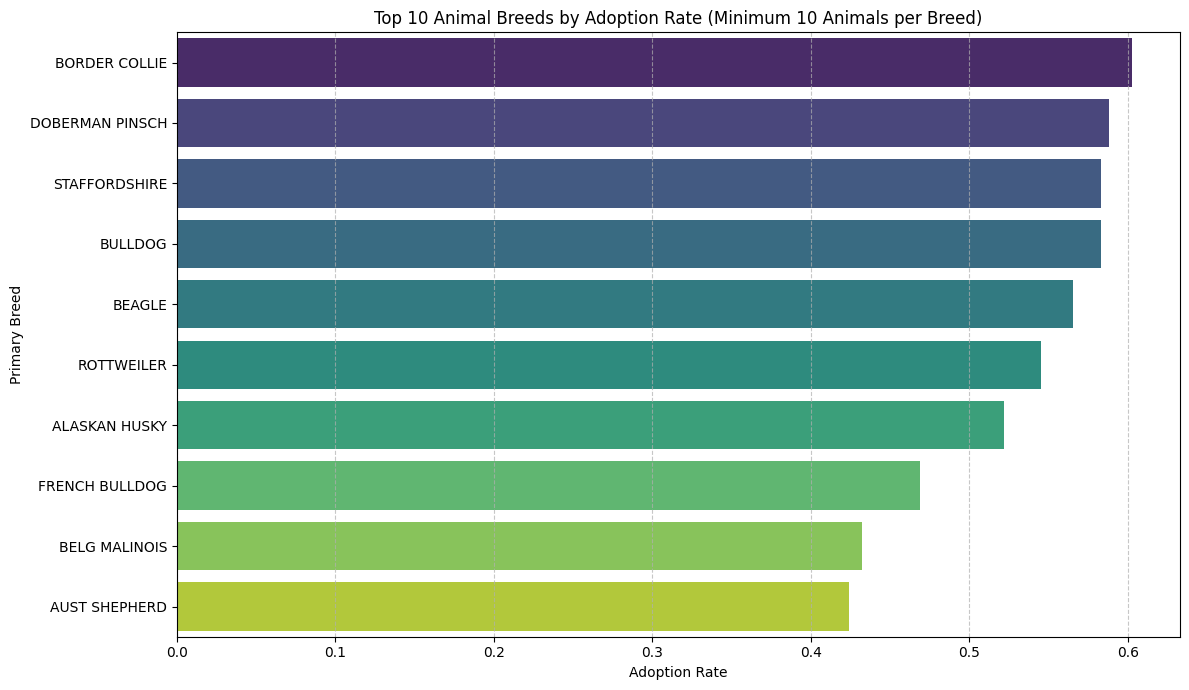

Adoption rates for top 10 breeds with at least 10 animals:
PrimaryBreed
BORDER COLLIE      0.602740
DOBERMAN PINSCH    0.588235
STAFFORDSHIRE      0.583333
BULLDOG            0.583333
BEAGLE             0.565217
ROTTWEILER         0.545455
ALASKAN HUSKY      0.521739
FRENCH BULLDOG     0.469027
BELG MALINOIS      0.432432
AUST SHEPHERD      0.424242
Name: IsAdoptedFlag, dtype: float64


In [ ]:
#Dogs with the highest adoption rates
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

breed_counts = df['PrimaryBreed'].value_counts()
min_count = 10 # midigates small sample size bias
relevant_breeds = breed_counts[breed_counts >= min_count].index

#only using primary breeds
df_filtered_breeds = df[df['PrimaryBreed'].isin(relevant_breeds)]

adoption_rates_filtered = df_filtered_breeds.groupby('PrimaryBreed')['IsAdoptedFlag'].mean().sort_values(ascending=False)

top_10_filtered_breeds = adoption_rates_filtered.head(10)

# Plot
plt.figure(figsize=(12, 7))
sns.barplot(y=top_10_filtered_breeds.index, x=top_10_filtered_breeds.values, palette='viridis')
plt.title(f'Top 10 Animal Breeds by Adoption Rate (Minimum {min_count} Animals per Breed)')
plt.ylabel('Primary Breed')
plt.xlabel('Adoption Rate')
plt.xticks(rotation=0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Adoption rates for top 10 breeds with at least {min_count} animals:")
print(top_10_filtered_breeds)

/tmp/ipykernel_2520/2898825065.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adoption_rates_by_age = df.groupby('AgeGroup')['IsAdoptedFlag'].mean().sort_values(ascending=False)
/tmp/ipykernel_2520/2898825065.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=adoption_rates_by_age.index.astype(str), x=adoption_rates_by_age.values, palette='viridis')


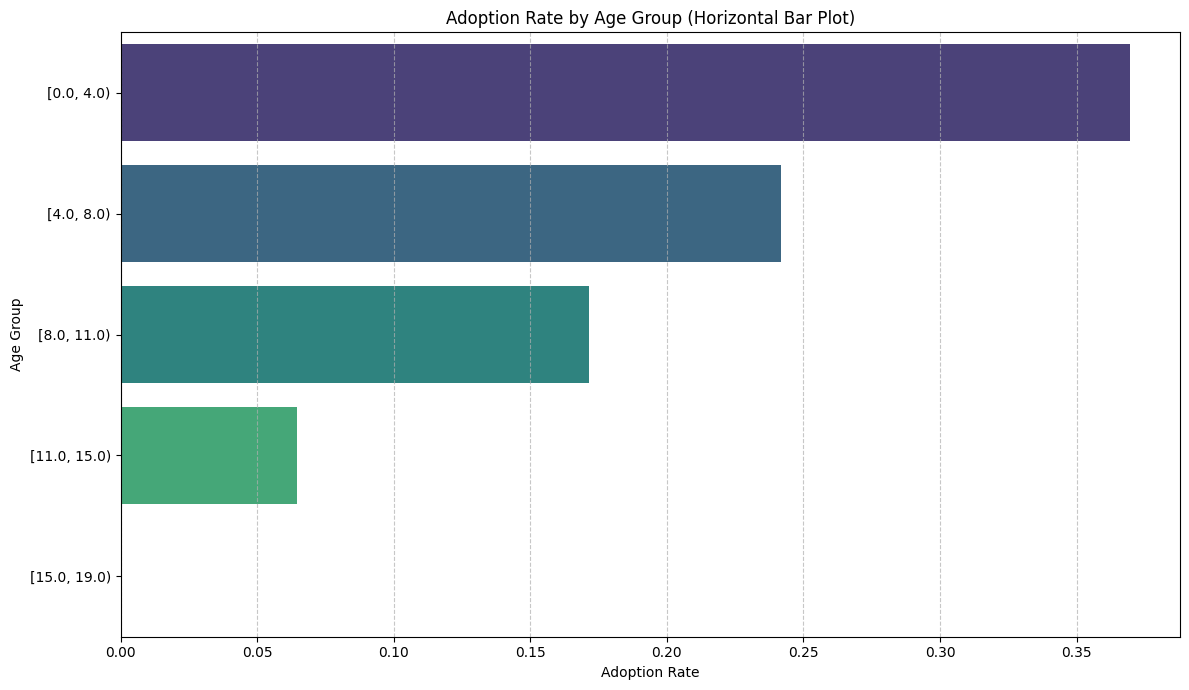

Adoption rates by Age Group:
AgeGroup
[0.0, 4.0)      0.369401
[4.0, 8.0)      0.241935
[8.0, 11.0)     0.171429
[11.0, 15.0)    0.064516
[15.0, 19.0)    0.000000
Name: IsAdoptedFlag, dtype: float64


In [ ]:
# PC
# Age and adoption rates

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df['AgeGroup'] = pd.cut(df['Age'], bins=5, precision=0, right=False)

adoption_rates_by_age = df.groupby('AgeGroup')['IsAdoptedFlag'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 7))
sns.barplot(y=adoption_rates_by_age.index.astype(str), x=adoption_rates_by_age.values, palette='viridis')
plt.title('Adoption Rate by Age Group (Horizontal Bar Plot)')
plt.ylabel('Age Group')
plt.xlabel('Adoption Rate')
plt.xticks(rotation=0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Adoption rates by Age Group:")
print(adoption_rates_by_age)

/tmp/ipykernel_2520/2580688629.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')


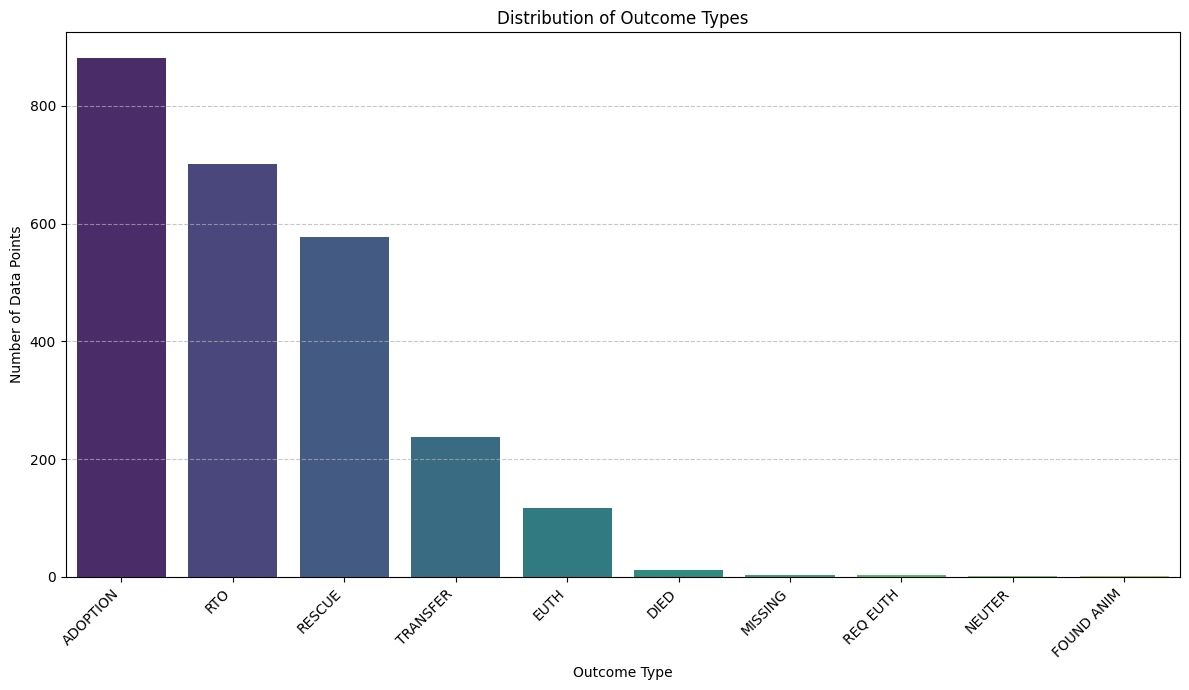

Counts of each Outcome Type:
OutcomeType
ADOPTION      881
RTO           702
RESCUE        577
TRANSFER      238
EUTH          117
DIED           12
MISSING         4
REQ EUTH        3
NEUTER          1
FOUND ANIM      1
Name: count, dtype: int64


In [ ]:
# How many dogs/puppies fall into each outcome type

import matplotlib.pyplot as plt
import seaborn as sns
outcome_counts = df['OutcomeType'].value_counts()

# Plot
plt.figure(figsize=(12, 7))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')
plt.title('Distribution of Outcome Types')
plt.xlabel('Outcome Type')
plt.ylabel('Number of Data Points')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Counts of each Outcome Type:")
print(outcome_counts)

## Logistic Regression

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


In [ ]:
# One-hot-encoding the other variables
df_oh = pd.get_dummies(df, columns=['AnimalType', 'PrimaryColor','SecondaryColor','PrimaryBreed', 'Sex', 'IntakeCondition','IntakeType','IntakeSubtype','IntakeReason', 'Crossing','Jurisdiction' ])
df_oh.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765 entries, 1 to 6975
Columns: 1849 entries, AnimalID to Jurisdiction_SUNNYVALE
dtypes: bool(1838), category(1), datetime64[ns](3), float64(2), int64(2), object(3)
memory usage: 5.1+ MB


In [ ]:
# Creating x and y
df['IsAdoptedFlag'] = (df['OutcomeType'] == 'ADOPTION').astype(int)

# Create the target variable (y) from the original DataFrame df
y = df['IsAdoptedFlag']
x = df_oh.drop(columns=['IsAdoptedFlag','AnimalID', 'IntakeDate', 'OutcomeDate', 'OutcomeSubtype', 'LastUpdate', 'OutcomeType','OutcomeCondition'], errors='ignore')

x.head()

,Age,DaysInShelter,AgeGroup,AnimalType_DOG,AnimalType_PUPPY,PrimaryColor_APRICOT,PrimaryColor_BLACK,PrimaryColor_BLUE,PrimaryColor_BR BRINDLE,PrimaryColor_BRINDLE-BN,...,Jurisdiction_COUNTY,Jurisdiction_CUPERTINO,Jurisdiction_LOS GATOS,Jurisdiction_MILPITAS,Jurisdiction_MOUNTAIN VIEW,Jurisdiction_OUT OF COUNTY,Jurisdiction_SAN JOSE,Jurisdiction_SANTA CLARA,Jurisdiction_SARATOGA,Jurisdiction_SUNNYVALE
1,17.0,1,"[15.0, 19.0)",True,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,14.0,0,"[11.0, 15.0)",True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
5,16.0,15,"[15.0, 19.0)",True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
6,13.0,22,"[11.0, 15.0)",True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
7,12.0,7,"[11.0, 15.0)",True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
import numpy as np
# Fill NaN values in 'Age' column of x with its median
x['Age'].fillna(x['Age'].median(), inplace=True)

# Drop the 'AgeGroup' column as it is not numerical and 'Age' is already present
x = x.drop(columns=['AgeGroup'], errors='ignore')

# Test Train split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=144)

lr = LogisticRegression(penalty=None, max_iter=1000)
lr.fit(x_train, y_train)
lr.coef_

/tmp/ipykernel_2520/2122606391.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['Age'].fillna(x['Age'].median(), inplace=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    http

array([[-3.25730866e-01, -7.49848308e-05, -5.00009972e+00, ...,
         2.91063915e-01,  2.66840398e+00, -1.99839084e+00]])

In [ ]:
# Finding the Coefficents and their corresponding feature
feature_names = x_train.columns
coefficients = lr.coef_[0] # lr.coef_ is a 2D array, even for binary classification

coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

display(coefficients_df.sort_values(by='Coefficient', ascending=False))

,Feature,Coefficient
173,Sex_NEUTERED,20.496822
174,Sex_SPAYED,20.175274
50,PrimaryBreed_AM PIT BULL TER,3.833608
69,PrimaryBreed_BORDER COLLIE,3.398197
59,PrimaryBreed_AUST SHEPHERD,3.296700
...,...,...
1554,Crossing_SEVEN TREES BLVD / SAN MATEO DR,-3.649758
561,Crossing_CHESTNUT ST/VERMONT ST,-3.852161
2,AnimalType_DOG,-5.000100
171,Sex_FEMALE,-21.526938


In [ ]:
# 5 largest coefficients
print("\nTop 5 largest coefficients:")
display(coefficients_df.sort_values(by='Coefficient', ascending=False).head(5))

# 5 smallest coefficients
print("\nTop 5 smallest coefficients:")
display(coefficients_df.sort_values(by='Coefficient', ascending=True).head(5))


Top 5 largest coefficients:


,Feature,Coefficient
173,Sex_NEUTERED,20.496822
174,Sex_SPAYED,20.175274
50,PrimaryBreed_AM PIT BULL TER,3.833608
69,PrimaryBreed_BORDER COLLIE,3.398197
59,PrimaryBreed_AUST SHEPHERD,3.296700



Top 5 smallest coefficients:


,Feature,Coefficient
172,Sex_MALE,-24.199322
171,Sex_FEMALE,-21.526938
2,AnimalType_DOG,-5.000100
561,Crossing_CHESTNUT ST/VERMONT ST,-3.852161
1554,Crossing_SEVEN TREES BLVD / SAN MATEO DR,-3.649758


In [ ]:
# Predictions
y_pred_lr = lr.predict(x_test)
y_proba_lr = lr.predict_proba(x_test)[:, 1]

# Evaluation metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("=== Logistic Regression Performance ===")
print(f"Accuracy:  {acc_lr:.3f}")
print(f"Precision: {prec_lr:.3f}")
print(f"Recall:    {rec_lr:.3f}")
print(f"F1-score:  {f1_lr:.3f}")
print(f"ROC-AUC:   {auc_lr:.3f}")

=== Logistic Regression Performance ===
Accuracy:  0.843
Precision: 0.741
Recall:    0.780
F1-score:  0.760
ROC-AUC:   0.911


In [ ]:
# Metrics
from sklearn.metrics import roc_auc_score, r2_score, mean_squared_error, accuracy_score
y_test_pred = lr.predict(x_test)
y_test_prob = lr.predict_proba(x_test)
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

y_pred = lr.predict_proba(x_test)[:,1]

# Compute the confusion matrix with any chosen threshold
threshold = 0.5
confusion_matrix(y_test,y_pred >= threshold)
auc = roc_auc_score(y_test, y_pred)
print("Out-of-sample AUC:", auc)

accuracy = accuracy_score(y_test, y_test_pred)
print("Out-of-sample Accuracy:", accuracy)

Out-of-sample AUC: 0.9105966912945712
Out-of-sample Accuracy: 0.8433734939759037


## Random Forest

In [ ]:
#Train Random Forest classifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

rf.fit(x_train, y_train)

# Predictions
y_pred_rf = rf.predict(x_test)
y_proba_rf = rf.predict_proba(x_test)[:, 1]

# Evaluation metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("=== Random Forest Performance ===")
print(f"Accuracy:  {acc_rf:.3f}")
print(f"Precision: {prec_rf:.3f}")
print(f"Recall:    {rec_rf:.3f}")
print(f"F1-score:  {f1_rf:.3f}")
print(f"ROC-AUC:   {auc_rf:.3f}")

=== Random Forest Performance ===
Accuracy:  0.827
Precision: 0.656
Recall:    0.955
F1-score:  0.778
ROC-AUC:   0.930


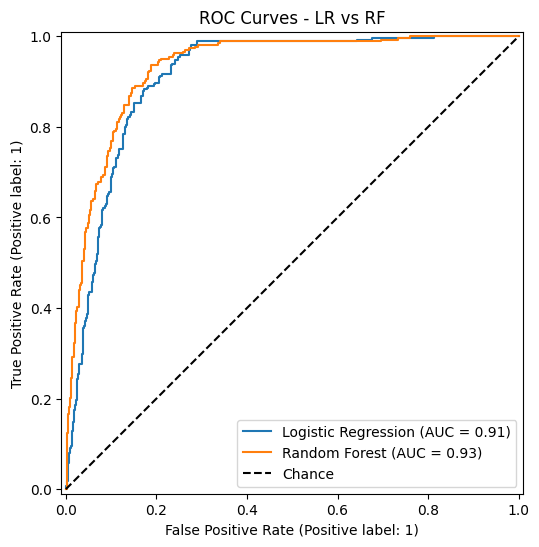

In [ ]:
#Compare ROC curves of LR vs RF

plt.figure(figsize=(6, 6))
ax = plt.gca()
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=ax)
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.title("ROC Curves - LR vs RF")
plt.legend()
plt.show()

## Cross Validation

In [ ]:
# Stratified 5-fold CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# Base Random Forest model
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

# Hyperparameter grid to search
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV
grid_rf.fit(x_train, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best RF ROC-AUC (CV):", grid_rf.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best RF ROC-AUC (CV): 0.9232206455456613


In [ ]:
# Evaluate the best Random Forest model from GridSearchCV
rf_best = grid_rf.best_estimator_

# Predictions with the best RF model
y_pred_rf_best = rf_best.predict(x_test)
y_proba_rf_best = rf_best.predict_proba(x_test)[:, 1]

# Evaluation metrics for the best RF model
acc_rf_best = accuracy_score(y_test, y_pred_rf_best)
prec_rf_best = precision_score(y_test, y_pred_rf_best)
rec_rf_best = recall_score(y_test, y_pred_rf_best)
f1_rf_best = f1_score(y_test, y_pred_rf_best)
auc_rf_best = roc_auc_score(y_test, y_proba_rf_best)

print("=== Optimized Random Forest Performance ===")
print(f"Accuracy:  {acc_rf_best:.3f}")
print(f"Precision: {prec_rf_best:.3f}")
print(f"Recall:    {rec_rf_best:.3f}")
print(f"F1-score:  {f1_rf_best:.3f}")
print(f"ROC-AUC:   {auc_rf_best:.3f}")

=== Optimized Random Forest Performance ===
Accuracy:  0.893
Precision: 0.830
Recall:    0.833
F1-score:  0.832
ROC-AUC:   0.953


In [ ]:
# Base Logistic Regression model
lr_base = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# Hyperparameter grid to search for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Set up GridSearchCV for Logistic Regression
grid_lr = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV
grid_lr.fit(x_train, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best LR ROC-AUC (CV):", grid_lr.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best LR params: {'C': 0.1, 'penalty': 'l1'}
Best LR ROC-AUC (CV): 0.9020294535915376


In [ ]:
# Evaluate the best Logistic Regression model from GridSearchCV
lr_best = grid_lr.best_estimator_

# Predictions with the best LR model
y_pred_lr_best = lr_best.predict(x_test)
y_proba_lr_best = lr_best.predict_proba(x_test)[:, 1]

# Evaluation metrics for the best LR model
acc_lr_best = accuracy_score(y_test, y_pred_lr_best)
prec_lr_best = precision_score(y_test, y_pred_lr_best)
rec_lr_best = recall_score(y_test, y_pred_lr_best)
f1_lr_best = f1_score(y_test, y_pred_lr_best)
auc_lr_best = roc_auc_score(y_test, y_proba_lr_best)

print("=== Optimized Logistic Regression Performance ===")
print(f"Accuracy:  {acc_lr_best:.3f}")
print(f"Precision: {prec_lr_best:.3f}")
print(f"Recall:    {rec_lr_best:.3f}")
print(f"F1-score:  {f1_lr_best:.3f}")
print(f"ROC-AUC:   {auc_lr_best:.3f}")

=== Optimized Logistic Regression Performance ===
Accuracy:  0.858
Precision: 0.734
Recall:    0.867
F1-score:  0.795
ROC-AUC:   0.919


In [ ]:
import os

# Create a directory to save the data if it doesn't exist
output_dir = 'cleaned_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the cleaned training and testing data to CSV files
x_train.to_csv(os.path.join(output_dir, 'x_train.csv'), index=False)
y_train.to_csv(os.path.join(output_dir, 'y_train.csv'), index=False)
x_test.to_csv(os.path.join(output_dir, 'x_test.csv'), index=False)
y_test.to_csv(os.path.join(output_dir, 'y_test.csv'), index=False)

print(f"Cleaned training and test data saved to the '{output_dir}' directory.")

Cleaned training and test data saved to the 'cleaned_data' directory.


In [ ]:
rfbest = grid_rf.best_estimator_

In [ ]:
import joblib
import pandas as pd
import numpy as np

# Final chosen model
final_model = rfbest

# Save training columns for future alignment
training_columns = x_train.columns.tolist()
joblib.dump(final_model, "rfbest_adoption_model.joblib")
joblib.dump(training_columns, "rfbest_training_columns.joblib")

# Create scored test set for inspection
test_results = pd.DataFrame({
    "actual": y_test.values,
    "pred_prob_adopt": final_model.predict_proba(x_test)[:, 1],
    "pred_label": final_model.predict(x_test)
}, index=x_test.index)

test_results["error_flag"] = (test_results["actual"] != test_results["pred_label"]).astype(int)
test_results.head()

,actual,pred_prob_adopt,pred_label,error_flag
4486,0,0.620,1,1
5868,1,0.585,1,0
6008,0,0.310,0,0
155,0,0.350,0,0
1937,1,0.600,1,0


In [ ]:
import joblib
import pandas as pd
import os

model = joblib.load("rfbest_adoption_model.joblib")
training_columns = joblib.load("rfbest_training_columns.joblib")

x_test_loaded = pd.read_csv("cleaned_data/x_test.csv", index_col=0)
y_test_loaded = pd.read_csv("cleaned_data/y_test.csv").squeeze().astype(int)

x_test_aligned = x_test_loaded.reindex(columns=training_columns, fill_value=0)

scored_animals = pd.DataFrame(index=x_test_aligned.index)
scored_animals["pred_prob_adopt"] = model.predict_proba(x_test_aligned)[:, 1]
scored_animals["pred_label"] = model.predict(x_test_aligned)
scored_animals["actual"] = y_test_loaded.values

# Create the directory if it doesn't exist
os.makedirs('deployment_artifacts', exist_ok=True)
scored_animals.to_csv("deployment_artifacts/scored_animals.csv")
scored_animals.head()

,pred_prob_adopt,pred_label,actual
Age,,,
1.0,0.590,1,0
5.0,0.845,1,1
3.0,0.370,0,0
1.0,0.340,0,0
5.0,0.770,1,1
